# 15. Plot Sparse CCA Results (2D vs 3D)

2D-vs-3D canonical score scatter (r and p-value shown per panel) for each profile-type pair computed in notebook 14. One clearly-titled plot per pair, saved with a matching filename prefix.

Feature loadings are saved in notebook 14 (`results/sparse_cca/<slug>_loadings_2d.parquet` / `..._loadings_3d.parquet`) but not plotted here — too many features get nonzero weight at the chosen penalty for a "top features" plot to be meaningful.

In [1]:
list_of_packages <- c("ggplot2", "dplyr", "arrow")

for (package in list_of_packages) {
    suppressPackageStartupMessages(
        suppressWarnings(
            library(
                package,
                character.only = TRUE,
                quietly = TRUE,
                warn.conflicts = FALSE
            )
        )
    )
}

In [2]:
find_git_root <- function() {
    cwd <- getwd()
    if (dir.exists(file.path(cwd, ".git"))) {
        return(cwd)
    }
    current_path <- cwd
    while (dirname(current_path) != current_path) {
        parent_path <- dirname(current_path)
        if (dir.exists(file.path(parent_path, ".git"))) {
            return(parent_path)
        }
        current_path <- parent_path
    }
    stop("No Git root directory found.")
}

root_dir <- find_git_root()
cat("Git root directory:", root_dir, "\n")

results_dir <- file.path(root_dir, "2.2d_vs_3d_analysis/results/sparse_cca")
figures_dir <- file.path(root_dir, "2.2d_vs_3d_analysis/figures/sparse_cca")
dir.create(figures_dir, recursive = TRUE, showWarnings = FALSE)

Git root directory: /Users/kaylorhuang/Documents/GitHub_Repos/Kaylor---NF1_organoid_profile_analysis 


### Profile-type pairs (must match notebook 14)

In [3]:
profile_pairs <- data.frame(
    label = c(
        "Organoid - Handcrafted",
        "Organoid - Deep Learning (SAM-Med3D)",
        "Single-cell - Handcrafted",
        "Single-cell - Deep Learning (SAM-Med3D)",
        "Single-cell - Nucleocentric DL (SAM-Med3D)",
        "Single-cell - Nucleocentric MorphEM (2D ViT)"
    ),
    slug = c(
        "organoid_handcrafted",
        "organoid_sammed",
        "sc_handcrafted",
        "sc_sammed",
        "sc_sammed_nucleocentric",
        "sc_nucleocentric_morphem"
    ),
    stringsAsFactors = FALSE
)

### Plot each pair's canonical score scatter, clearly titled and filed by slug

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


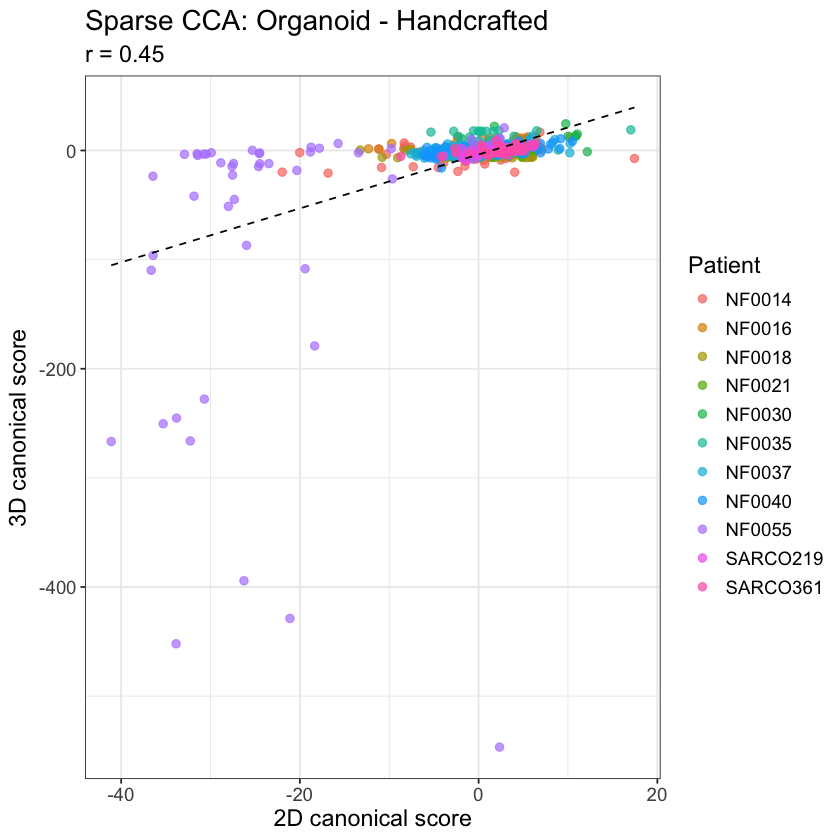

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


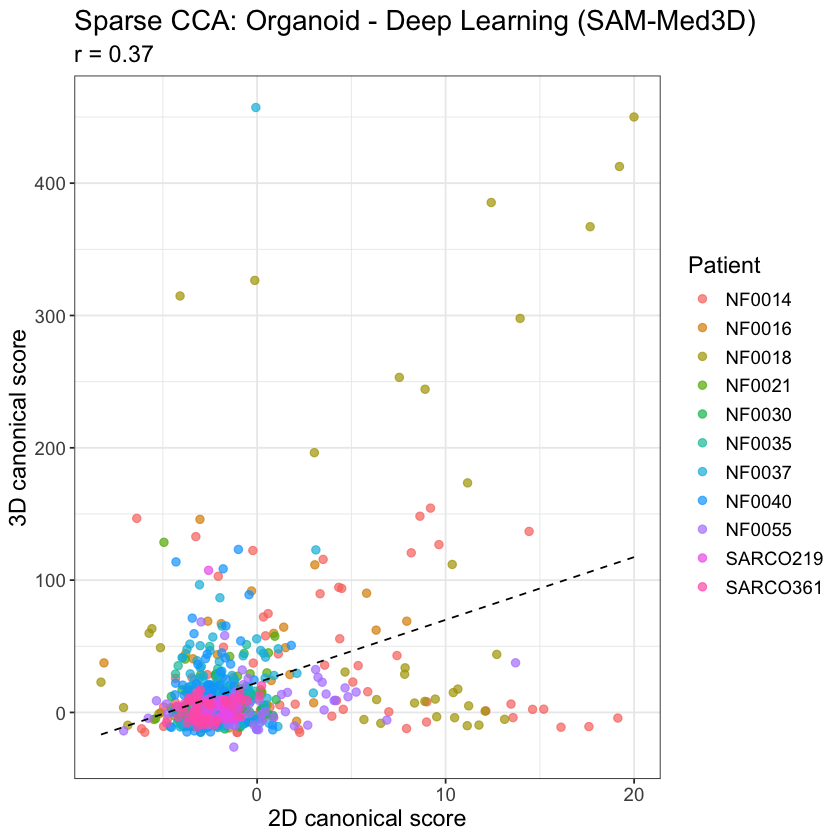

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


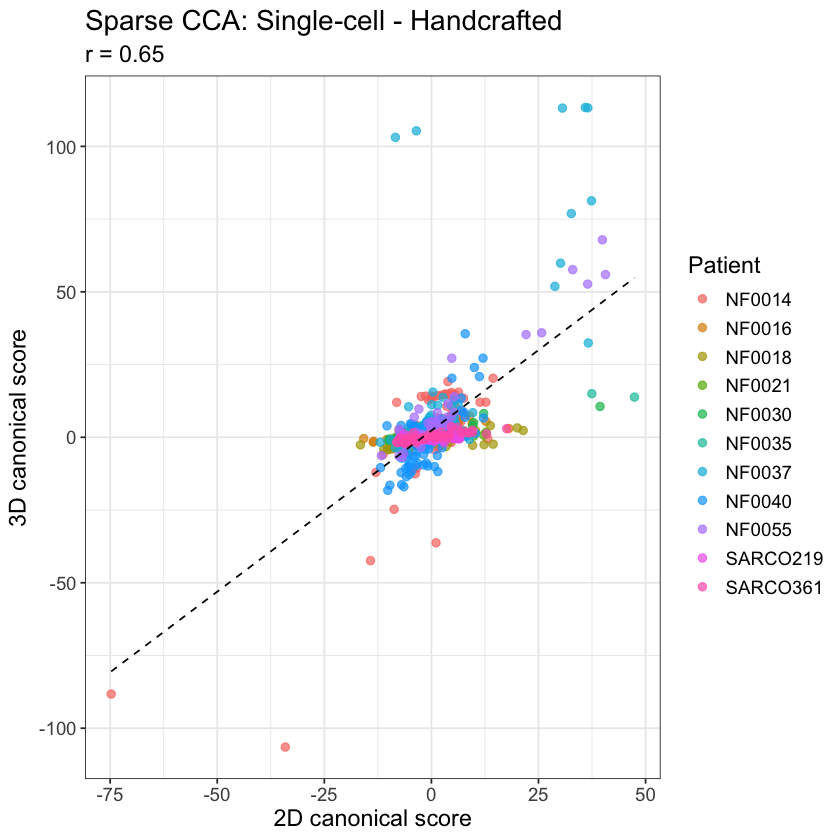

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


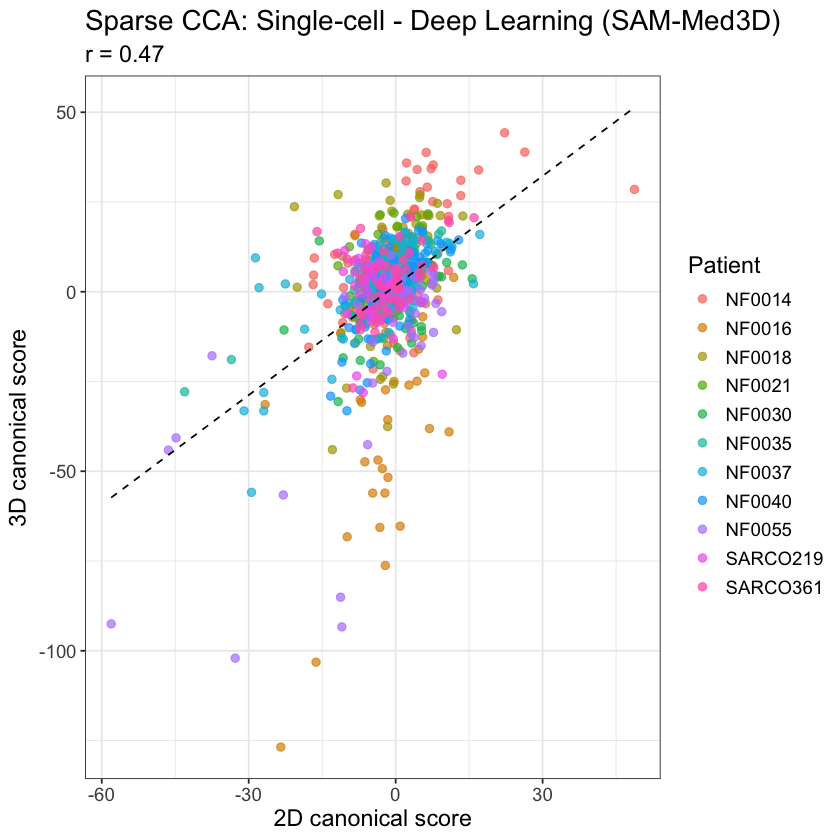

`geom_smooth()` using formula = 'y ~ x'


`geom_smooth()` using formula = 'y ~ x'


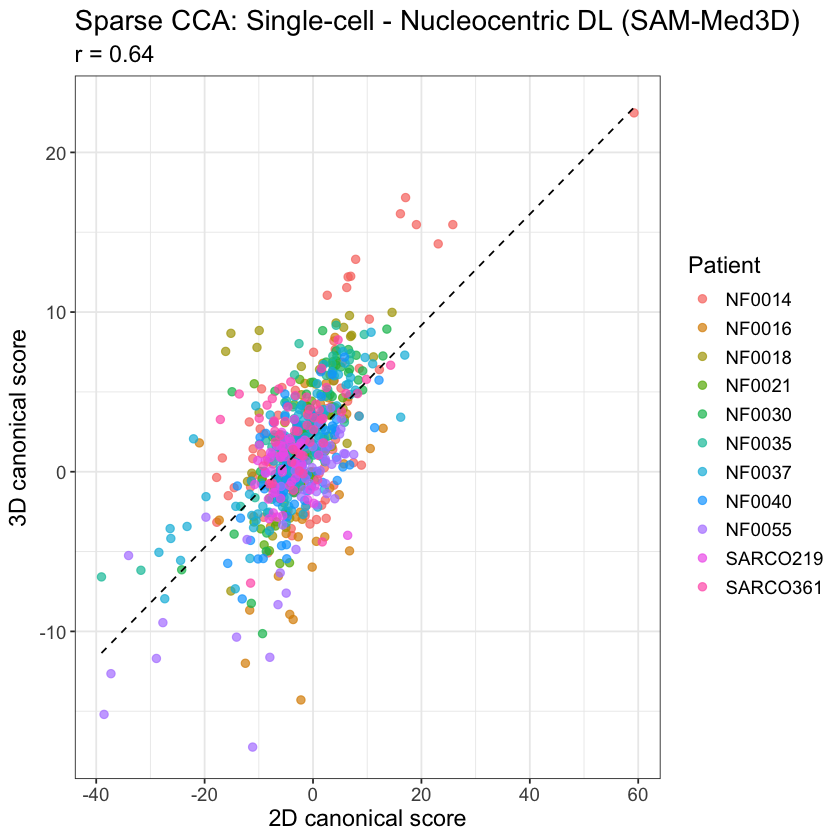

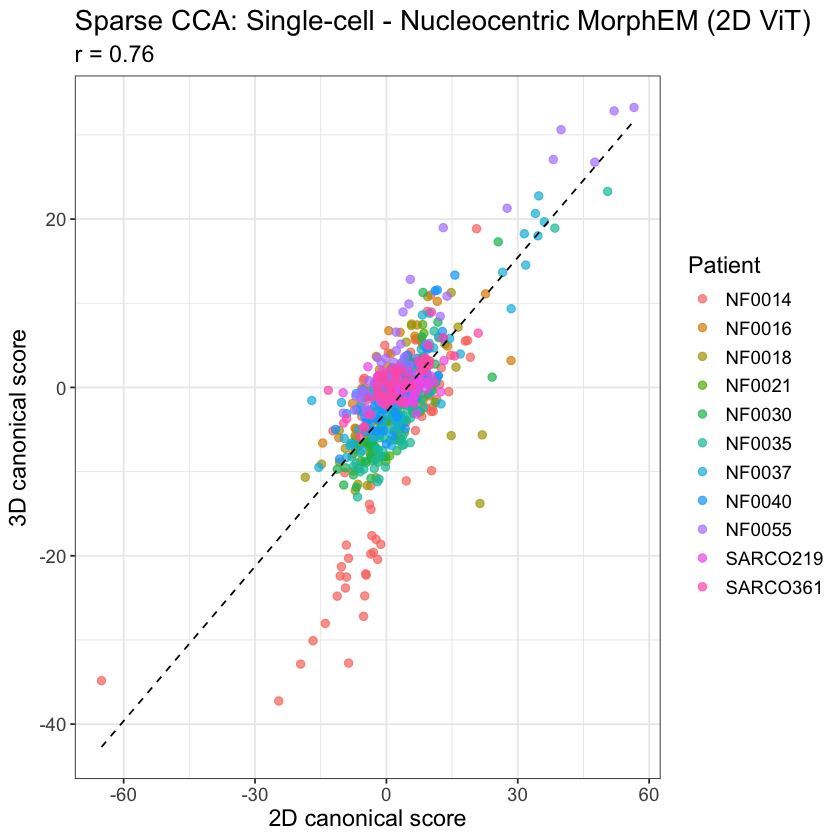

In [4]:
plot_pair <- function(label, slug, results_dir, figures_dir) {
    canonical_scores <- arrow::read_parquet(file.path(results_dir, paste0(slug, "_canonical_scores.parquet")))
    cor_summary <- arrow::read_parquet(file.path(results_dir, paste0(slug, "_canonical_correlations.parquet")))

    r_val <- round(cor_summary$canonical_correlation[1], 2)
    subtitle <- paste0("r = ", r_val)

    score_plot <- ggplot(canonical_scores, aes(x = CC1_2D, y = CC1_3D, color = Metadata_patient)) +
        geom_point(alpha = 0.7, size = 2) +
        geom_smooth(method = "lm", se = FALSE, color = "black", linetype = "dashed", linewidth = 0.5) +
        labs(
            title = paste0("Sparse CCA: ", label),
            subtitle = subtitle,
            x = "2D canonical score",
            y = "3D canonical score",
            color = "Patient"
        ) +
        theme_bw() +
        theme(text = element_text(size = 14))

    print(score_plot)
    ggsave(
        file.path(figures_dir, paste0("sparse_cca_", slug, "_score_scatter.png")),
        score_plot, width = 7, height = 6, dpi = 300, units = "in"
    )
}

for (i in seq_len(nrow(profile_pairs))) {
    plot_pair(profile_pairs$label[i], profile_pairs$slug[i], results_dir, figures_dir)
}